In [1]:
! pip install torch torchvision torchaudio
! pip install pandas pillow scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

In [3]:

df= pd.read_csv("data/challenge-2019-training_metadata_2026-02-20.csv")
df.head()

,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,clin_size_long_diam_mm,concomitant_biopsy,dermoscopic_type,diagnosis_1,...,diagnosis_4,diagnosis_5,diagnosis_confirm_type,family_hx_mm,image_type,lesion_id,melanocytic,patient_id,personal_hx_mm,sex
0,ISIC_0000000,Anonymous,CC-0,55.0,anterior torso,NaN,NaN,False,NaN,Benign,...,"Nevus, Atypical, Dysplastic, or Clark","Nevus, Dysplastic",NaN,NaN,dermoscopic,NaN,True,NaN,NaN,female
1,ISIC_0000001,Anonymous,CC-0,30.0,anterior torso,NaN,NaN,False,NaN,Benign,...,"Nevus, Atypical, Dysplastic, or Clark","Nevus, Dysplastic",NaN,NaN,dermoscopic,NaN,True,NaN,NaN,female
2,ISIC_0000002,Anonymous,CC-0,60.0,upper extremity,NaN,NaN,True,NaN,Malignant,...,NaN,NaN,histopathology,NaN,dermoscopic,NaN,True,NaN,NaN,female
3,ISIC_0000003,Anonymous,CC-0,30.0,upper extremity,NaN,NaN,False,NaN,Benign,...,"Nevus, Atypical, Dysplastic, or Clark","Nevus, Dysplastic",NaN,NaN,dermoscopic,NaN,True,NaN,NaN,male
4,ISIC_0000004,Anonymous,CC-0,80.0,posterior torso,NaN,NaN,True,NaN,Malignant,...,NaN,NaN,histopathology,NaN,dermoscopic,NaN,True,NaN,NaN,male


In [4]:
df.isnull().sum().sort_values(ascending=False)

diagnosis_5               24917
patient_id                24914
family_hx_mm              24786
personal_hx_mm            24776
clin_size_long_diam_mm    24775
anatom_site_special       24371
diagnosis_4               24355
dermoscopic_type          23901
anatom_site_general        2582
diagnosis_confirm_type     2459
lesion_id                  1667
age_approx                  482
sex                         384
diagnosis_3                 255
copyright_license             0
attribution                   0
isic_id                       0
concomitant_biopsy            0
diagnosis_2                   0
diagnosis_1                   0
image_type                    0
melanocytic                   0
dtype: int64

In [5]:
#  Supprimer Indeterminate
df = df[df["diagnosis_1"] != "Indeterminate"]

#  Supprimer colonnes inutilisables
cols_to_drop = [
    "diagnosis_5",
    "patient_id",
    "family_hx_mm",
    "personal_hx_mm",
    "clin_size_long_diam_mm",
    "diagnosis_4",
    "anatom_site_special",
    "dermoscopic_type"
]

df = df.drop(columns=cols_to_drop)

#  Supprimer lignes sans lesion_id
df = df[df["lesion_id"].notna()]

#  valeurs manquantes restantes
df["age_approx"] = df["age_approx"].fillna(df["age_approx"].median())
df["sex"] = df["sex"].fillna("unknown")
df["anatom_site_general"] = df["anatom_site_general"].fillna("unknown")
df["diagnosis_confirm_type"] = df["diagnosis_confirm_type"].fillna("unknown")
df["diagnosis_3"] = df["diagnosis_3"].fillna("unknown")

#  Encoder la cible
df["label"] = df["diagnosis_1"].map({
    "Benign": 0,
    "Malignant": 1
})

#  Vérification finale
print("Final dataset size:", len(df))
print(df["label"].value_counts())

#  Sauvegarde 
df.to_csv("data/isic2019_clean.csv", index=False)

Final dataset size: 22797
label
0    14584
1     8213
Name: count, dtype: int64


In [6]:

# Récupérer lesions uniques
unique_lesions = df["lesion_id"].unique()

# Split lesions
train_lesions, temp_lesions = train_test_split(
    unique_lesions,
    test_size=0.3,
    random_state=42
)

val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.5,
    random_state=42
)

# Créer splits
train_df = df[df["lesion_id"].isin(train_lesions)]
val_df = df[df["lesion_id"].isin(val_lesions)]
test_df = df[df["lesion_id"].isin(test_lesions)]

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

train_df.to_csv("data/Train_Test/train_split.csv", index=False)
val_df.to_csv("data/Train_Test/val_split.csv", index=False)
test_df.to_csv("data/Train_Test/test_split.csv", index=False)

Train: 16003
Val: 3376
Test: 3418


In [7]:
# Dataset PyTorch
class ISICDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row["isic_id"] + ".jpg")

        image = Image.open(img_path).convert("RGB")
        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
# Transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [9]:
# DataLoaders
train_dataset = ISICDataset("data/Train_Test/train_split.csv", "data/images", transform=train_transform)
val_dataset = ISICDataset("data/Train_Test/val_split.csv", "data/images", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [10]:
# Modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

c:\Users\angea\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\angea\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
# Loss et Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [12]:
# Entraînement
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [13]:
# Évaluation
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [14]:
# Training loop
for epoch in range(5):
    loss = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

Epoch 1
Train Loss: 0.4145
Val Accuracy: 0.8110
Epoch 2
Train Loss: 0.3256
Val Accuracy: 0.8196
Epoch 3
Train Loss: 0.2623
Val Accuracy: 0.8045
Epoch 4
Train Loss: 0.2044
Val Accuracy: 0.8187
Epoch 5
Train Loss: 0.1626
Val Accuracy: 0.8104


In [ ]:
# Sauvegarder le meilleur modèle
best_val_acc = 0

for epoch in range(5):
    loss = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(" Modèle sauvegardé")

In [ ]:
# Évaluation complète
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

def evaluate_full(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze()   # <-- important
            preds = (probs > 0.5).int()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    #  Flatten pour éviter le broadcasting
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    all_probs = np.array(all_probs).flatten()

    acc = (all_preds == all_labels).sum() / len(all_labels)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    print("Accuracy:", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))
    print("AUC:", round(auc, 4))

In [ ]:
# Charger le meilleur modèle et évaluer
model.load_state_dict(torch.load("best_model.pth"))
evaluate_full(model, val_loader)

Accuracy: 0.8246
Precision: 0.7615
Recall: 0.7425
F1-score: 0.7519
AUC: 0.8964


In [ ]:
# Prédiction sur une image individuelle

def predict_image(model, image_path):
    model.eval()
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        prob = torch.sigmoid(output).item()

    return prob

In [ ]:
# Exemple d'utilisation
score = predict_image(model, "data/images/ISIC_0013497.jpg")
print(score)

0.9665506482124329


In [ ]:
# Interprétation du score
def risk_level(score):
    if score <= 0.33:
        return "Low"
    elif score <= 0.66:
        return "Moderate"
    else:
        return "High"

In [ ]:
# Exemple d'utilisation
score = 0.72
print(risk_level(score))

High


In [ ]:
# Matrice de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
#courbe ROC
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    auc = roc_auc_score(all_labels, all_probs)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

Accuracy: 0.8246
Precision: 0.7615
Recall: 0.7425
F1-score: 0.7519
AUC: 0.8964


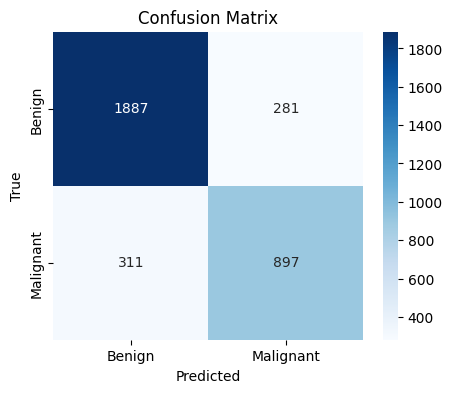

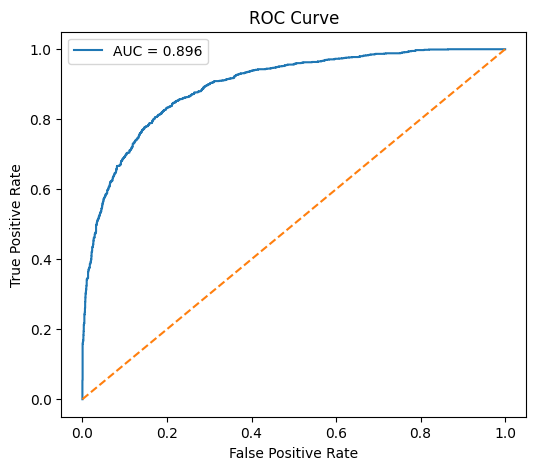

In [ ]:
# Charger le meilleur modèle et évaluer
model.load_state_dict(torch.load("best_model.pth"))

evaluate_full(model, val_loader)
plot_confusion_matrix(model, val_loader)
plot_roc_curve(model, val_loader)

In [ ]:
# Sauvegarder le modèle final
torch.save({
    "model_state_dict": model.state_dict(),
    "model_name": "resnet18",
    "num_classes": 1
}, "dermai_resnet18.pth")

print(" Modèle sauvegardé proprement")

 Modèle sauvegardé proprement


In [ ]:

from torchvision.models import resnet18

def load_model(model_path):
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)

    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

    model.to(device)
    model.eval()

    return model

In [ ]:
def debug_predict(model, image_path):
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        logit = output.item()
        prob = torch.sigmoid(output).item()

    print("Logit:", logit)
    print("Prob:", prob)

In [ ]:
# Charger le modèle EXACTEMENT comme pendant évaluation
model = resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()

score = predict_image(model, sample_image_path)
print(score)

5.398392399769136e-09


In [ ]:
#Test complet pipeline inference
loaded_model = load_model("dermai_resnet18.pth")

score = predict_image(loaded_model, sample_image_path)
print("Score image:", score)
print("Risk level:", risk_level(score))

Score image: 5.398392399769136e-09
Risk level: Low


In [ ]:
import re

#  Prétraitement du texte

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text



#  Extraction durée


def extract_duration(text):
    weeks = 0

    # Extraction semaines
    match_weeks = re.search(r"(\d+)\s*(semaine|semaines|week|weeks)", text)
    if match_weeks:
        weeks = int(match_weeks.group(1))

    # Extraction mois (conversion en semaines)
    match_months = re.search(r"(\d+)\s*(mois|month|months)", text)
    if match_months:
        weeks = int(match_months.group(1)) * 4

    return weeks



#  Extraction douleur (binaire)


def extract_pain(text):
    pain_keywords = ["douleur", "pain", "mal", "sensible"]
    return any(word in text for word in pain_keywords)



# Extraction autres symptômes


def extract_binary_symptoms(text):
    return {
        "itching": any(word in text for word in ["demange", "démange", "itch"]),
        "bleeding": any(word in text for word in ["saigne", "bleed"]),
        "growth": any(word in text for word in ["grossi", "grossit", "augmente", "grow"])
    }



# Calcul score pondéré


def compute_symptom_score(duration_weeks, pain_present, symptoms):
    score = 0

    # Durée prolongée
    if duration_weeks > 6:
        score += 0.2
    if duration_weeks > 12:
        score += 0.1

    # Douleur
    if pain_present:
        score += 0.2

    # Saignement (indicateur fort)
    if symptoms["bleeding"]:
        score += 0.3

    # Croissance
    if symptoms["growth"]:
        score += 0.2

    # Démangeaison
    if symptoms["itching"]:
        score += 0.1

    return min(score, 1.0)



# Pipeline complet NLP


def analyze_text(text):
    text = preprocess_text(text)

    duration = extract_duration(text)
    pain = extract_pain(text)
    symptoms = extract_binary_symptoms(text)

    score = compute_symptom_score(duration, pain, symptoms)

    return {
        "duration_weeks": duration,
        "pain": pain,
        "itching": symptoms["itching"],
        "bleeding": symptoms["bleeding"],
        "growth": symptoms["growth"],
        "score_symptomes": score
    }

In [ ]:
# Exemple d'utilisation
text = "La lésion est présente depuis 8 semaines, elle saigne et a grossi récemment."

result = analyze_text(text)

print(result)

{'duration_weeks': 8, 'pain': False, 'itching': False, 'bleeding': True, 'growth': True, 'score_symptomes': 0.7}


In [ ]:
import requests

def generate_llm_recommendation(score_image, score_symptomes, score_global, nlp_result):

    risk = determine_risk_level(score_global)

    prompt = f"""
Tu es une intelligence artificielle d'aide à l'orientation dermatologique.

Règles importantes :
- Tu ne dois JAMAIS poser de diagnostic médical.
- Tu dois uniquement donner une recommandation d’orientation.
- Tu dois toujours inclure une phrase précisant que ceci ne remplace pas un avis médical.
- Le ton doit être clair, professionnel et rassurant.
- Maximum 5 phrases.

Niveau de risque estimé : {risk}
Score image : {score_image}
Score symptômes : {score_symptomes}

Symptômes détectés :
- Saignement : {nlp_result['bleeding']}
- Croissance récente : {nlp_result['growth']}
- Douleur : {nlp_result['pain']}
- Durée (semaines) : {nlp_result['duration_weeks']}

Rédige une recommandation adaptée pour le grand public.
"""

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3",  # adapte si besoin
            "prompt": prompt,
            "stream": False,
            "temperature": 0.3  # faible pour réponse plus stable
        }
    )

    return response.json()["response"]

In [ ]:
#  Analyse NLP
nlp_result = analyze_text(text)
score_symptomes = nlp_result["score_symptomes"]

#  Fusion
score_global = compute_global_score(score_image, score_symptomes)

#  Niveau de risque
risk = determine_risk_level(score_global)

#  Génération LLM
llm_text = generate_llm_recommendation(
    score_image,
    score_symptomes,
    score_global,
    nlp_result
)

print("Score image :", score_image)
print("Score symptômes :", score_symptomes)
print("Score global :", score_global)
print("Risk level :", risk)
print("\nRecommandation :\n")
print(llm_text)

NameError: name 'analyze_text' is not defined